In [45]:
import torch as tc
import numpy as np
import qutip as qt
import function as my
import matplotlib.pyplot as plt
from tqdm import tqdm

class SIN(tc.nn.Module):
    def __init__(self): 
        super(SIN, self).__init__() 
    def forward(self, x):
        return tc.sin(x)

In [46]:
tfinal      = 2*np.pi
N           = 200
Nedo        = 15
Nfield      = 1

J, omega2 = (1,.5)
gamma1=0.0; gamma2=0.0; gamma3=0.0; gamma4=0.0
D1 = -gamma1/2 - 2*gamma2    # decaimento de Q1 (transversal)
D3 = -gamma3/2 - 2*gamma4    # decaimento de Q2 (transversal)

epocas  = 100000

# Hamiltonina de dois quibts

$$H_0 = \frac{\omega_2}{2}(\hat{\sigma}_z \otimes \hat{I}) + g*((\hat{\sigma}_x \otimes \hat{\sigma}_x) + (\hat{\sigma}_y \otimes \hat{\sigma}_y))$$

$$H_1 = \hat{I} \otimes \hat{\sigma}_z$$

$$H(t) = H_0 + f(t)* H_1$$

Ou de forma expandida:

$$\boxed{H(t) = \frac{\omega_2}{2}\hat{\sigma}_z^{(1)} \otimes \hat{I}^{(2)} + g\left(\hat{\sigma}_x^{(1)} \otimes \hat{\sigma}_x^{(2)} + \hat{\sigma}_y^{(1)} \otimes \hat{\sigma}_y^{(2)}\right) + f(t)*\hat{I}^{(1)} \otimes \hat{\sigma}_z^{(2)}}$$

onde $f(t)$ é o campo externo a ser aprendido pela PINN, o termo de acoplamento $g(\hat{\sigma}_x \otimes \hat{\sigma}_x + \hat{\sigma}_y \otimes \hat{\sigma}_y)$ representa a interação do tipo XY entre os dois qubits, e os superíndices $(1)$ e $(2)$ indicam em qual qubit cada operador atua.

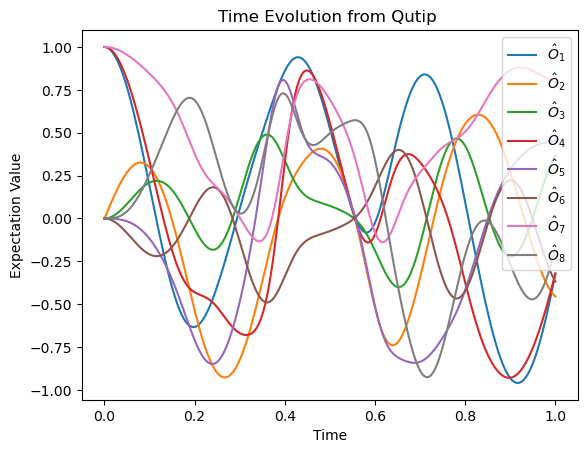

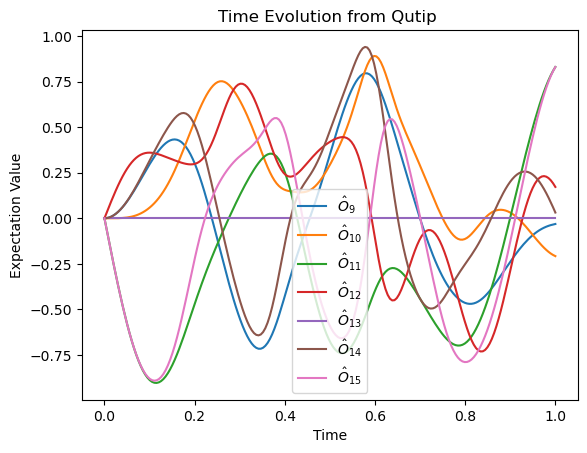

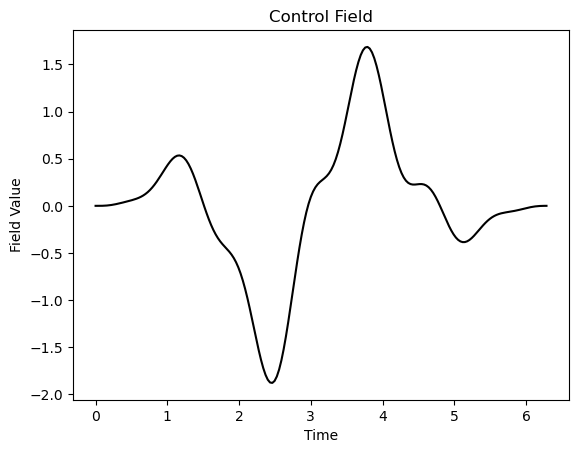

In [47]:
O_op =[ qt.tensor(qt.sigmax(), qt.qeye(2)),
        qt.tensor(qt.sigmay(), qt.qeye(2)),
        qt.tensor(qt.sigmaz(), qt.qeye(2)),
        qt.tensor(qt.qeye(2), qt.sigmax()),
        qt.tensor(qt.qeye(2), qt.sigmay()),
        qt.tensor(qt.qeye(2), qt.sigmaz()),
        qt.tensor(qt.sigmax(), qt.sigmax()),
        qt.tensor(qt.sigmax(), qt.sigmay()),
        qt.tensor(qt.sigmax(), qt.sigmaz()),
        qt.tensor(qt.sigmay(), qt.sigmay()),
        qt.tensor(qt.sigmay(), qt.sigmaz()),
        qt.tensor(qt.sigmay(), qt.sigmax()),
        qt.tensor(qt.sigmaz(), qt.sigmaz()),
        qt.tensor(qt.sigmaz(), qt.sigmax()),
        qt.tensor(qt.sigmaz(), qt.sigmay()),
        ]

def Field(t):
    return ( 1.5* np.sin(2.0 * t) - 0.3*np.cos(3* t - 0.5) + 0.4*np.sin(7.0 * t)
    )*np.sin(np.pi*t/tfinal)**2
    #return 0.5* np.cos( t) 

def data_qubit(O_op,tlist,field,device="cpu", g=1, omega2=0.5, gamma1=0., gamma3=0., gamma2=0., gamma4=0.):
    # Lista de tempos para a evolução
    H0 =  omega2*qt.tensor(qt.sigmaz(), qt.qeye(2)) + g*(qt.tensor(qt.sigmax(), qt.sigmax()) + qt.tensor(qt.sigmay(), qt.sigmay()))
    
    H1 = qt.tensor(qt.qeye(2), qt.sigmaz()) 
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    if gamma1 > 0:
        c_ops.append(np.sqrt(gamma1) * qt.tensor(qt.create(2), qt.qeye(2)))  # σ+⊗I
    if gamma3 > 0:
        c_ops.append(np.sqrt(gamma3) * qt.tensor(qt.qeye(2), qt.create(2)))  # I⊗σ+
    if gamma2 > 0:
        c_ops.append(np.sqrt(gamma2) * qt.tensor(qt.destroy(2), qt.qeye(2)))  # σ-⊗I
    if gamma4 > 0:
        c_ops.append(np.sqrt(gamma4) * qt.tensor(qt.qeye(2), qt.destroy(2)))  # I⊗σ-
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = qt.tensor(ket_plus1, ket_plus1)
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    return tc.tensor( np.array( result.expect),device = device).transpose(0, 1)

tlist = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(
    O_op,tlist,Field,
    device = "cpu",
    g = J,
    omega2 = omega2,
    gamma1 = gamma1, gamma3=gamma3, gamma2=gamma2, gamma4=gamma4)

for i in range(8):
    plt.plot(tlist/tfinal,valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$" )
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()

for i in range(8,len(O_op)):
    plt.plot(tlist/tfinal,valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$" )
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()


plt.plot(tlist,Field(tlist),'k-')
plt.xlabel('Time')
plt.ylabel('Field Value')
#plt.legend()
plt.title('Control Field')
plt.show()


In [48]:
neuronio = [10,10]
X_vector   = my.Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = Nedo+Nfield,
    activation  =[SIN()]*len(neuronio))

neuronio = [5,5]
p_vector   = my.Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = 1,
    activation  =[SIN()]*len(neuronio))

opt = tc.optim.Adam(list(X_vector.parameters()) + list(p_vector.parameters()),
        lr = 0.001 )
time =  tc.linspace(
        0,
        tfinal,
        N,
        dtype   = tc.float32,
        requires_grad = True).reshape((-1, 1))

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [06:41<00:00, 248.76it/s]


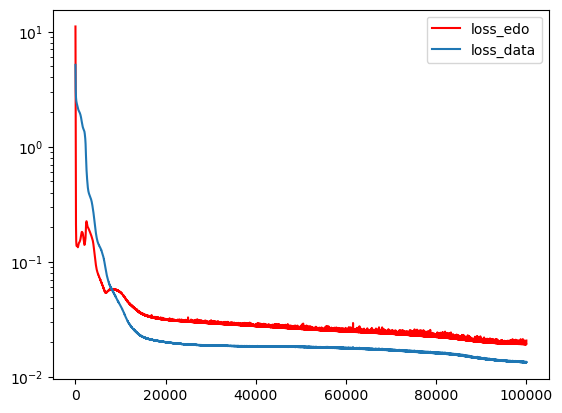

In [49]:
LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y = X_vector(time)
    omega1 = p_vector(time) # campo f(t) a ser encontrado (coeficiente de IZ)

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]-1):
        dX_dt.append(tc.autograd.grad(outputs = y[:, i],
                                    inputs = time,
                                    grad_outputs = tc.ones_like(y[:, i]),
                                    #retain_graph = True,
                                    create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
 
    IX,IY,IZ     = y[:, 0:1], y[:, 1:2], y[:, 2:3],
    XI,XX_,XY,XZ = y[:, 3:4], y[:, 4:5], y[:, 5:6], y[:, 6:7]
    YI,YX,YY_,YZ = y[:, 7:8], y[:, 8:9], y[:, 9:10], y[:, 10:11]
    ZI,ZX,ZY,ZZ  = y[:, 11:12], y[:, 12:13], y[:, 13:14], y[:, 14:15]
    II = tc.ones_like(IX)  # <II> = 1 sempre
    
    dIX,dIY,dIZ,dXI,dXX,dXY,dXZ = dX_dt[:, 0:1], dX_dt[:, 1:2], dX_dt[:, 2:3], dX_dt[:, 3:4], dX_dt[:, 4:5], dX_dt[:, 5:6], dX_dt[:, 6:7]
    dYI,dYX,dYY,dYZ,dZI,dZX,dZY,dZZ = dX_dt[:, 7:8], dX_dt[:, 8:9], dX_dt[:, 9:10], dX_dt[:, 10:11], dX_dt[:, 11:12], dX_dt[:, 12:13], dX_dt[:, 13:14], dX_dt[:, 14:15]
    
    # H = omega2*ZI + J*(XX+YY) + omega1(t)*IZ
    # [ZI, O] -> coef. omega2 (estatico, qubit 1: XI, YI, ...)
    # [IZ, O] -> coef. omega1 (campo aprendido, qubit 2: IX, IY, ...)
    # [XX+YY, O] -> coef. J (estatico, acoplamento)
    LOSS_edo  = 0
    LOSS_edo += (dIX - (D3*IX    - 2*omega1*IY  + 2*J*YZ ))**2   # [IZ,IX]=2i*IY -> -2*f*IY
    LOSS_edo += (dIY - (2*omega1*IX + D3*IY    - 2*J*XZ))**2     # [IZ,IY]=-2i*IX -> +2*f*IX
    LOSS_edo += (dIZ - (-gamma3*II + (-gamma3)*IZ + 2*J*XY - 2*J*YX))**2  # so J
    LOSS_edo += (dXI - (D1*XI    - 2*omega2*YI  + 2*J*ZY))**2    # [ZI,XI]=2i*YI -> -2*omega2*YI
    LOSS_edo += (dXX - ((D1+D3)*XX_ - 2*omega1*XY - 2*omega2*YX))**2  # [IZ,XX]=2i*XY; [ZI,XX]=2i*YX
    LOSS_edo += (dXY - (-2*J*IZ + 2*omega1*XX_ + (D1+D3)*XY - 2*omega2*YY_ + 2*J*ZI))**2
    LOSS_edo += (dXZ - (2*J*IY  - gamma3*XI   + (D1 - gamma3)*XZ - 2*omega2*YZ))**2  # [ZI,XZ]=2i*YZ
    LOSS_edo += (dYI - (2*omega2*XI + D1*YI    - 2*J*ZX))**2     # [ZI,YI]=-2i*XI -> +2*omega2*XI
    LOSS_edo += (dYX - (2*J*IZ  + 2*omega2*XX_ + (D1+D3)*YX - 2*omega1*YY_ - 2*J*ZI))**2
    LOSS_edo += (dYY - (2*omega2*XY + 2*omega1*YX + (D1+D3)*YY_))**2  # [ZI,YY]=-2i*XY; [IZ,YY]=-2i*YX
    LOSS_edo += (dYZ - (-2*J*IX  + 2*omega2*XZ - gamma3*YI + (D1 - gamma3)*YZ))**2  # [ZI,YZ]=-2i*XZ
    LOSS_edo += (dZI - (-gamma1*II - 2*J*XY + 2*J*YX - gamma1*ZI))**2  # so J
    LOSS_edo += (dZX - (-gamma1*IX + 2*J*YI + (-gamma1+D3)*ZX - 2*omega1*ZY))**2  # [IZ,ZX]=2i*ZY -> -2*f*ZY
    LOSS_edo += (dZY - (-gamma1*IY - 2*J*XI + 2*omega1*ZX + (-gamma1+D3)*ZY))**2  # [IZ,ZY]=-2i*ZX -> +2*f*ZX
    LOSS_edo += (dZZ - (-gamma1*IZ - gamma3*ZI + (-gamma1 - gamma3)*ZZ))**2
    LOSS_edo = LOSS_edo.mean()

    ####### loss data(expected values) #######
    LOSS_data = 0
    LOSS_data +=(IX  - valor_esperado_data[:,3:4])**2
    LOSS_data +=(IY  - valor_esperado_data[:,4:5])**2
    LOSS_data +=(IZ  - valor_esperado_data[:,5:6])**2
    LOSS_data +=(XI  - valor_esperado_data[:,0:1])**2
    LOSS_data +=(XX_ - valor_esperado_data[:,6:7])**2
    LOSS_data +=(XY  - valor_esperado_data[:,7:8])**2
    LOSS_data +=(XZ  - valor_esperado_data[:,8:9])**2
    LOSS_data +=(YI  - valor_esperado_data[:,1:2])**2
    LOSS_data +=(YX  - valor_esperado_data[:,11:12])**2
    LOSS_data +=(YY_ - valor_esperado_data[:,9:10])**2
    LOSS_data +=(YZ  - valor_esperado_data[:,10:11])**2
    LOSS_data +=(ZI  - valor_esperado_data[:,2:3])**2
    LOSS_data +=(ZX  - valor_esperado_data[:,13:14])**2
    LOSS_data +=(ZY  - valor_esperado_data[:,14:15])**2
    LOSS_data +=(ZZ  - valor_esperado_data[:,12:13])**2
    LOSS_data = LOSS_data.mean()
    
    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

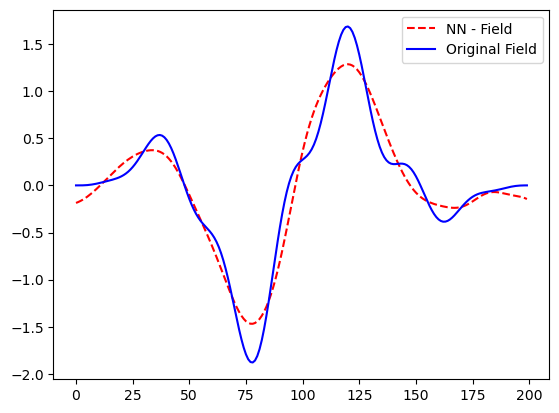

In [50]:
t_points =  np.linspace(0,tfinal, N)
X_vector.eval()
X_  = p_vector(time).detach().numpy()

field_original=Field(t_points)
plt.plot(X_,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

/tmp/ipykernel_35515/1883415376.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


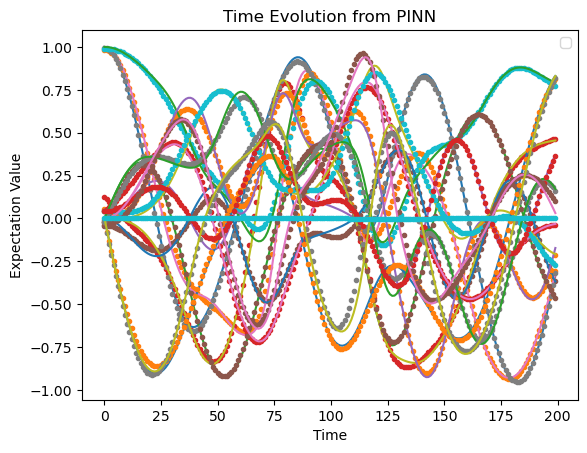

In [51]:
t_points =  np.linspace(0,tfinal, N)
X_vector.eval()
X_  = X_vector(time).detach().numpy()

for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() 
             )
    plt.plot(X_[:,i],"." ,)
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()
